In [5]:
import seaborn
import matplotlib.pyplot as plt
from libpysal.weights import lag_spatial
import geopandas as gpd
from libpysal.weights import Queen

In [6]:
# setting wd 
import os
os.chdir('/users/ctlin/fooddesertproject')

In [60]:
county = "tarrant"
County= "Tarrant"

In [26]:
gdf = gpd.read_file(f"extra_figures/modeling_data/{county}_modeling_final.gpkg")
print(gdf.shape)  

(389, 24)


In [5]:
# # only use when calculating k, otherwise comment out 
# n = len(gdf)
# k = round(n ** (1/3))
# print(f"Number of census tracts: {n}")
# print(f"Cube root of n: {n**(1/3):.2f}")
# print(f"Selected k: {k}")

Number of census tracts: 1289
Cube root of n: 10.88
Selected k: 11


In [61]:
# gdf = gpd.read_file(f"modeling_data/{county}_modeling_final.gpkg")
# w1 = KNN.from_dataframe(gdf, k=k, use_index=True)

gdf = gpd.read_file(f"extra_figures/modeling_data/{county}_modeling_final.gpkg")
w1 = Queen.from_dataframe(gdf, use_index=True)

In [62]:
# standardize your variable (subtract the mean) — makes the plot easier to read
gdf["var_std"] = gdf["E_DIABETES"] - gdf["E_DIABETES"].mean()

In [63]:
# compute the spatial lag — average of each tract's neighbors
w1.transform = "R"  # row-standardize for the plot (safe here since you're not calling higher_order after this)
gdf["var_lag_std"] = lag_spatial(w1, gdf["var_std"])

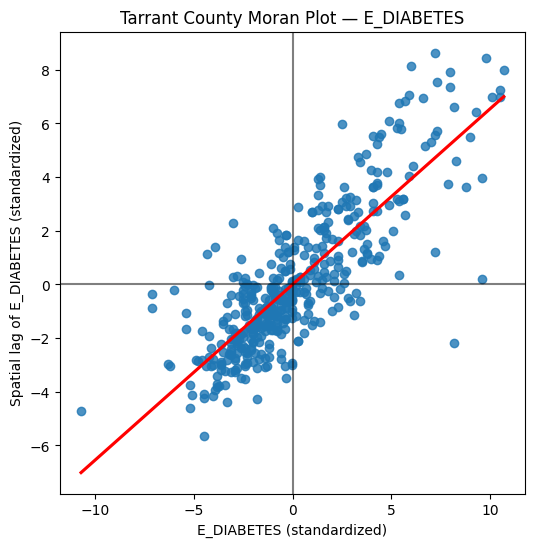

In [64]:
# plot
f, ax = plt.subplots(1, figsize=(6, 6))
seaborn.regplot(
    x="var_std", y="var_lag_std", data=gdf,
    ci=None, line_kws={"color": "r"}
)
ax.axvline(0, c="k", alpha=0.5)
ax.axhline(0, c="k", alpha=0.5)
ax.set_xlabel("E_DIABETES (standardized)")
ax.set_ylabel("Spatial lag of E_DIABETES (standardized)")
ax.set_title(f"{County} County Moran Plot — E_DIABETES")
plt.savefig(f"{county}_moran_plot_diabetes.png", dpi=200, bbox_inches="tight")
plt.show()

In [65]:
from PIL import Image

filenames = [
    "bexar_moran_plot_diabetes.png",
    "dallas_moran_plot_diabetes.png",
    "travis_moran_plot_diabetes.png",
    "tarrant_moran_plot_diabetes.png",
    "harris_moran_plot_diabetes.png"
]
images = [Image.open(f) for f in filenames]

thumb_w, thumb_h = 450, 425
resized_images = []
for img in images:
    img_copy = img.copy()
    img_copy.thumbnail((thumb_w, thumb_h), Image.Resampling.LANCZOS)  # preserves aspect ratio
    # paste centered onto a white cell of consistent size
    cell = Image.new("RGB", (thumb_w, thumb_h), "white")
    x = (thumb_w - img_copy.width) // 2
    y = (thumb_h - img_copy.height) // 2
    cell.paste(img_copy, (x, y))
    resized_images.append(cell)

grid_canvas = Image.new("RGB", (thumb_w * 3, thumb_h * 2), "white")
positions = [
    (0, 0), (thumb_w, 0), (thumb_w * 2, 0),
    (0, thumb_h), (thumb_w, thumb_h)
]
for img, pos in zip(resized_images, positions):
    grid_canvas.paste(img, pos)

grid_canvas.show()
grid_canvas.save("all_metros_integrated_map.png", dpi=(300, 300))

FileNotFoundError: [Errno 2] No such file or directory: 'bexar_moran_plot_diabetes.png'